In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.3 MB/s eta 0:00:39
    --------------------------------------- 0.8/48.9 MB 1.3 MB/s eta 0:00:38
    --------------------------------------- 1.0/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 1.3/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 1.6/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 1.8/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 2.1/48.9 MB 1.3 MB/s eta 0:00:38
   - -------------------------------------- 2.4/48.9 MB 1.3 MB/s eta 0:00:37
   -- ------------------------------------- 2.6/48.9 MB 1.3 MB/s eta 0:00:37
   -- ------------------------------------- 2.9/48.9 MB 1.3 MB/s eta 0:00:37
   -- --------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import packages for data manipulation
import numpy as np
import pandas as pd
import requests

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

# Fetch Liiga dataset with a reliable timeout and user-agent
url = "https://liiga.fi/api/v2/games?season=2025"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(url, headers=headers, timeout=15)
data = response.json()

# Normalize JSON into DataFrame
df = pd.json_normalize(data)

cols = [
    "id",
    "homeTeam.teamName",
    "awayTeam.teamName",
    "homeTeam.goals",
    "awayTeam.goals",
    "homeTeam.expectedGoals",
    "awayTeam.expectedGoals",
    "spectators",
]

df_liiga = df[cols].copy()
df_liiga.columns = [
    "id",
    "home_team",
    "away_team",
    "home_goals",
    "away_goals",
    "home_xg",
    "away_xg",
    "spectators",
]

# Drop missing values and define target
df_clean = df_liiga.dropna(subset=['home_xg', 'away_xg', 'spectators']).copy()
df_clean["home_win"] = (df_clean["home_goals"] > df_clean["away_goals"]).astype(int)

print(f"Dataset shape: {df_clean.shape}")
df_clean.head()

Dataset shape: (582, 9)


,id,home_team,away_team,home_goals,away_goals,home_xg,away_xg,spectators,home_win
1,1007,Lukko,Ässät,2,0,1.80,0.77,4500,1
3,1009,Ässät,SaiPa,0,2,1.23,0.83,4500,0
4,1010,TPS,Sport,0,0,0.53,0.72,4500,0
5,1011,SaiPa,Lukko,1,0,1.18,0.54,4500,1
6,1012,Ässät,JYP,1,1,2.67,0.34,4500,0


In [4]:
# Check target class distribution
df_clean['home_win'].value_counts(normalize=True)

home_win
1    0.539519
0    0.460481
Name: proportion, dtype: float64

In [5]:
# Create working copy for modeling
ml_data = df_clean.copy()

# 1. Goal expectancy differential
ml_data['xg_diff'] = ml_data['home_xg'] - ml_data['away_xg']

# 2. Proportion of expected goals by home team
ml_data['home_xg_share'] = ml_data['home_xg'] / (ml_data['home_xg'] + ml_data['away_xg'] + 0.001)

# Isolate feature matrix (X) and target vector (y)
features = ['home_xg', 'away_xg', 'xg_diff', 'home_xg_share', 'spectators']
X = ml_data[features]
y = ml_data['home_win']

# Display first few rows
X.head()

,home_xg,away_xg,xg_diff,home_xg_share,spectators
1,1.80,0.77,1.03,0.700117,4500
3,1.23,0.83,0.40,0.596798,4500
4,0.53,0.72,-0.19,0.423661,4500
5,1.18,0.54,0.64,0.685648,4500
6,2.67,0.34,2.33,0.886749,4500


In [6]:
# Split the data into initial training+validation (80%) and test (20%) sets
X_tr, X_test, y_tr, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split the training data into final training (60%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(
    X_tr, y_tr, test_size=0.25, random_state=42, stratify=y_tr
)

# Confirm shapes align
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (348, 5), y_train shape: (348,)
X_val shape:   (117, 5), y_val shape:   (117,)
X_test shape:  (117, 5), y_test shape:  (117,)


In [7]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create parameter grid for tuning
cv_params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.6]
}

# Define evaluation metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Instantiate GridSearchCV targeting ROC-AUC
rf_cv = GridSearchCV(rf, cv_params_rf, scoring=scoring, cv=5, refit='roc_auc')

# Fit model
rf_cv.fit(X_train, y_train)

# Output best score and parameters
print(f"Best RF ROC-AUC: {rf_cv.best_score_:.4f}")
print("Best RF Parameters:", rf_cv.best_params_)

Best RF ROC-AUC: 0.6430
Best RF Parameters: {'max_depth': 3, 'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [8]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')

# Create parameter grid for tuning
cv_params_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3]
}

# Instantiate GridSearchCV targeting ROC-AUC
xgb_cv = GridSearchCV(xgb, cv_params_xgb, scoring=scoring, cv=5, refit='roc_auc')

# Fit model
xgb_cv.fit(X_train, y_train)

# Output best score and parameters
print(f"Best XGB ROC-AUC: {xgb_cv.best_score_:.4f}")
print("Best XGB Parameters:", xgb_cv.best_params_)

Best XGB ROC-AUC: 0.6223
Best XGB Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 50}


In [9]:
# Predict on validation data
y_val_rf = rf_cv.best_estimator_.predict(X_val)
y_val_xgb = xgb_cv.best_estimator_.predict(X_val)

target_names = ['Non-Home Win (0)', 'Home Win (1)']

print("--- Random Forest Validation Report ---")
print(classification_report(y_val, y_val_rf, target_names=target_names))

print("--- XGBoost Validation Report ---")
print(classification_report(y_val, y_val_xgb, target_names=target_names))

--- Random Forest Validation Report ---
                  precision    recall  f1-score   support

Non-Home Win (0)       0.47      0.35      0.40        54
    Home Win (1)       0.55      0.67      0.60        63

        accuracy                           0.52       117
       macro avg       0.51      0.51      0.50       117
    weighted avg       0.51      0.52      0.51       117

--- XGBoost Validation Report ---
                  precision    recall  f1-score   support

Non-Home Win (0)       0.50      0.28      0.36        54
    Home Win (1)       0.55      0.76      0.64        63

        accuracy                           0.54       117
       macro avg       0.53      0.52      0.50       117
    weighted avg       0.53      0.54      0.51       117



=== FINAL TEST REPORT (CHAMPION MODEL) ===
                  precision    recall  f1-score   support

Non-Home Win (0)       0.57      0.37      0.45        54
    Home Win (1)       0.59      0.76      0.66        63

        accuracy                           0.58       117
       macro avg       0.58      0.57      0.56       117
    weighted avg       0.58      0.58      0.56       117

Test ROC-AUC Score: 0.5883


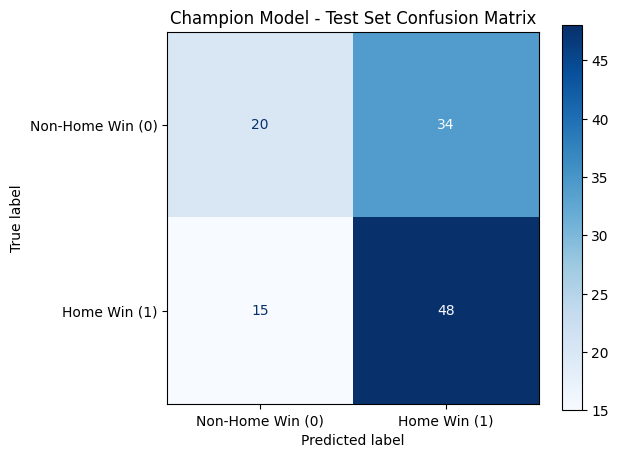

In [10]:
# Select the champion model (e.g., Random Forest or XGBoost based on validation performance)
champion_model = rf_cv.best_estimator_

# Predict on the unseen holdout test set
y_test_pred = champion_model.predict(X_test)
y_test_proba = champion_model.predict_proba(X_test)[:, 1]

print("=== FINAL TEST REPORT (CHAMPION MODEL) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

# Plot Confusion Matrix for Test Set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Champion Model - Test Set Confusion Matrix")
plt.grid(False)
plt.show()

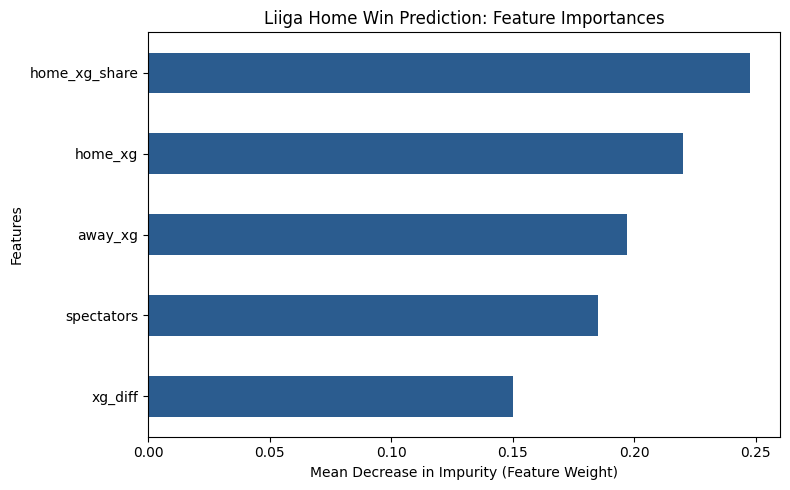

In [11]:
# Extract and plot feature importances from champion model
importances = pd.Series(champion_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2b5c8f')
plt.title("Liiga Home Win Prediction: Feature Importances")
plt.xlabel("Mean Decrease in Impurity (Feature Weight)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [12]:
import pickle

# ------------------------------------------------------------------------------
# 1. MODEL PERSISTENCE FUNCTIONS (PICKLE)
# ------------------------------------------------------------------------------
def write_pickle(path: str, model_object, save_as: str):
    """Saves a trained model object to a pickle file."""
    with open(f"{path}{save_as}.pickle", "wb") as to_write:
        pickle.dump(model_object, to_write)
    print(f"[✓] Model successfully saved to {path}{save_as}.pickle")

def read_pickle(path: str, saved_model_name: str):
    """Reads a pickled model object from disk."""
    with open(f"{path}{saved_model_name}.pickle", "rb") as to_read:
        model = pickle.load(to_read)
    print(f"[✓] Model successfully loaded from {path}{saved_model_name}.pickle")
    return model

# Save the champion model
save_path = "./"
write_pickle(save_path, champion_model, "liiga_champion_model")

# Verify that the model can be correctly loaded from disk
saved_champion = read_pickle(save_path, "liiga_champion_model")

[✓] Model successfully saved to ./liiga_champion_model.pickle
[✓] Model successfully loaded from ./liiga_champion_model.pickle
